In [ ]:
try:
    import google.colab
    %pip install -q ugropy
except ImportError:
    pass

# Filtering multiple solutions

Due to the nature of the `ugropy` algorithm, some molecules may present
multiple fragmentation solutions for a specific model. On such cases, the
experience of the user with a model may be sufficient to determine  
the most appropriate solution. Besides, `ugropy` provides some heuristic
methods to determine the "most correct solution" along with some criteria.

These methods are kind of easy to implement, and the user is invited to create
their own if it is found necessary.

On the `ugropy` library, the fragmentation models are instances of diverse
classes that require more or less information to describe a specific model.

All the fragmentation classes inherit from the base class `FragmentationModel`.
For that, some filters are implemented for the base class `FragmentationModel`
and are available for all the fragmentation models. Other filters are specific
to a subclass, for example, the `GibbsModel` (unifac, psrk, dortmund, etc).

**Recommendation**

**Is recommended to explore the "DDBST Validation" subsection on the "Tests book" section of this documentation to explore the performance of these filters on the UNIFAC model.**


All filters receive a list of solutions obtained by `ugropy` and return
another list of solutions that where filtered. Sometimes the length of the
returned list could be one (only on solution selected) other times could be
more (generally because the filter could not decide which one is best).

In [3]:
from ugropy import unifac

## FragmentationModel class filters

As said before, these filters are available for all the fragmentation models
and rely on basic heuristics. Let's check and explain each one:

### Filter: Mostly polyatomic

This filter selects the solution with the highest amount of atoms occupied
by polyatomic fragments (hydrogens doesn't count). Let's analyze the following
example that has two solutions:

In [10]:
solutions = unifac.get_groups("COC(=O)CC1=CC=CC=C1", "smiles", search_multiple_solutions=True) 

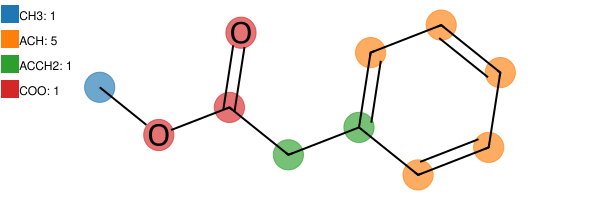

In [11]:
solutions[0].draw(width=600)

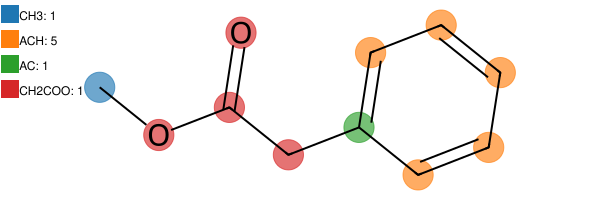

In [12]:
solutions[1].draw(width=600)

To use a filter for a model, we can use the filter methods implemented in that
model like the following:

In [13]:
filtered = unifac.filter_mostly_polyatomic(solutions)

len(filtered)

1

As you can observe, the filter found a unique preferred solution along with
its criteria. The solution is the one that uses the groups "COO" and "ACCH2"
since more atoms of the molecule are occupied by polyatomic fragments: 

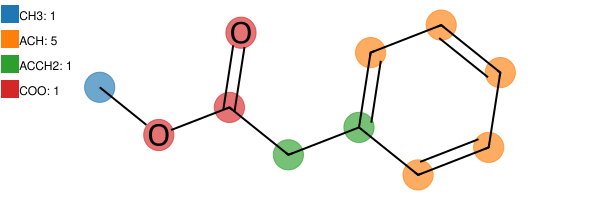

In [14]:
filtered[0].draw(width=600)

### Filter: Mostly polarity

This filter prefers the solutions that have the most atoms occupied by
fragments of and specified polarity. The arguments for the polarity could be
"polar" or "apolar" respectively. A group is considered polar if its SMARTS
pattern contains at least one of the following atoms: {"O", "N", "S", "P", "F",
"Cl", "Br", "I"}. Of course, a group is considered apolar if it does not contain
any of those atoms.

In [16]:
filtered_polarity = unifac.filter_mostly_polarity(solutions, polarity="polar")

len(filtered_polarity)

1

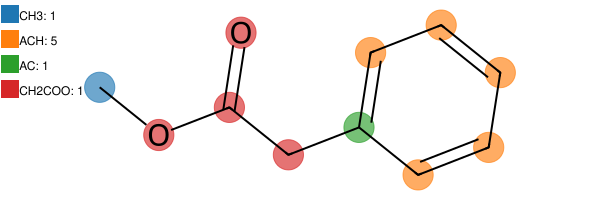

In [17]:
filtered_polarity[0].draw(width=600)

In this case, the other solution is preferred since the "CH2COO" (a polar
group) is occupying more atoms of the molecule. If we call the same filter
with the "apolar" argument:

In [18]:
filtered_polarity = unifac.filter_mostly_polarity(solutions, polarity="apolar")

len(filtered_polarity)

1

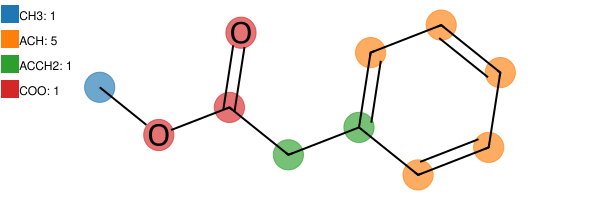

In [19]:
filtered_polarity[0].draw(width=600)

The other solution is preferred, since the "ACCH2" occupies and additional atom.

## GibbsModel class filters

These filters are available only for `GibbsModel`s fragmentation models since
they rely on the $R$ and $Q$ information about the groups.

### Filter: Polarity contribution (recommended)

This filter chooses the correct solution based on the total size of the
molecule occupied by groups of the specified polarity ("polar" or "apolar").
The size is either quantified by the $R$ or $Q$ values of the groups, specified
by the user. A group is considered polar if its SMARTS pattern contains at
least one of the following atoms: {"O", "N", "S", "P", "F", "Cl", "Br", "I"}.
Of course, a group is considered apolar if it does not contain any of those
atoms.


**This is the best found heuristic for GibbsModels configuring it to prioritize polar groups with the Q size criteria. Please refer to the DDBST Validation on the Tests book documentation to learn more.**


For the best heuristic found, the best solution is:

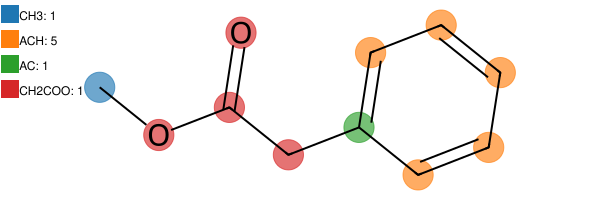

In [ ]:
filtered_polar_Q = unifac.filter_polarity_contribution(solutions, criteria="Q", polarity="polar")

filtered_polar_Q[0].draw(width=600)

Of course, you can change those configurations as you please:

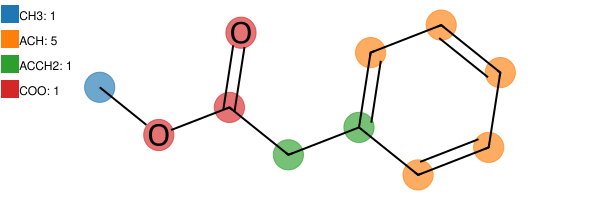

In [27]:
filtered_apolar_R = unifac.filter_polarity_contribution(solutions, criteria="R", polarity="apolar")

filtered_apolar_R[0].draw(width=600)

### Filter: Bigger polyatomics

This filter chooses the correct solution based on the total size of the
molecule occupied by polyatomic groups. The size is either quantified by the
$R$ or $Q$ values of the groups, specified by the user.

In [22]:
filtered_bigger_R = unifac.filter_bigger_polyatomics(solutions, criteria="R")

len(filtered_bigger_R)

1

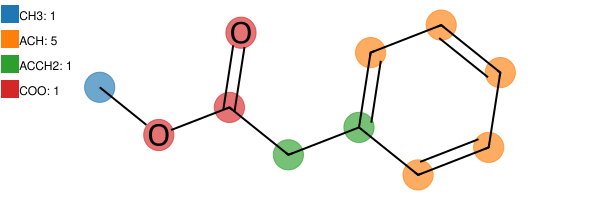

In [23]:
filtered_bigger_R[0].draw(width=600)

In [24]:
filtered_bigger_Q = unifac.filter_bigger_polyatomics(solutions, criteria="Q")

len(filtered_bigger_Q)

1

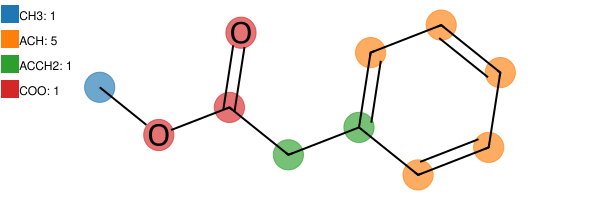

In [25]:
filtered_bigger_Q[0].draw(width=600)

On this case, it doesn't matter the selected size criteria, the same solution
is preferred.